## LAB 2

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

##Q1

In [2]:
X = torch.tensor([
    [1, 2, 0, 1, 3],
    [3, 1, 2, 2, 0],
    [0, 2, 3, 1, 1],
    [1, 0, 2, 3, 2],
    [2, 1, 0, 2, 1]
], dtype=torch.float32)

K = torch.tensor([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=torch.float32)

print("Input:")
print(X)

print("\nKernel:")
print(K)

Input:
tensor([[1., 2., 0., 1., 3.],
        [3., 1., 2., 2., 0.],
        [0., 2., 3., 1., 1.],
        [1., 0., 2., 3., 2.],
        [2., 1., 0., 2., 1.]])

Kernel:
tensor([[ 1.,  0., -1.],
        [ 2.,  0., -2.],
        [ 1.,  0., -1.]])


In [3]:
def manual_cross_correlation(X, K, padding=0):
    if padding > 0:
        X = F.pad(
            X.unsqueeze(0).unsqueeze(0),
            (padding, padding, padding, padding)
        ).squeeze()

    h, w = X.shape
    kh, kw = K.shape

    output_h = h - kh + 1
    output_w = w - kw + 1

    output = torch.zeros(output_h, output_w)

    for i in range(output_h):
        for j in range(output_w):
            window = X[i:i+kh, j:j+kw]
            output[i, j] = torch.sum(window * K)

    return output


output_no_padding = manual_cross_correlation(X, K, padding=0)

print("Output (stride=1, padding=0):")
print(output_no_padding)

Output (stride=1, padding=0):
tensor([[ 0.,  0.,  3.],
        [-6., -2.,  6.],
        [-3., -6.,  1.]])


In [4]:
output_padding = manual_cross_correlation(X, K, padding=1)

print("Output (stride=1, padding=1):")
print(output_padding)

Output (stride=1, padding=1):
tensor([[-5.,  3.,  1., -4.,  4.],
        [-6.,  0.,  0.,  3.,  6.],
        [-5., -6., -2.,  6.,  7.],
        [-3., -3., -6.,  1.,  9.],
        [-2.,  3., -5., -2.,  7.]])


## Q2. Tensor Dimension Analysis

Given input tensor:

128 × 128 × 3

Architecture:

Conv(32, 5×5, stride=2, padding=2)
→ ReLU
→ MaxPool(2×2, stride=2)
→ Conv(64, 3×3, stride=1, padding=1)
→ ReLU
→ MaxPool(2×2, stride=2)

For a convolution/pooling layer:

Output size = floor((N + 2P - K) / S) + 1

where:
N = input spatial dimension
P = padding
K = kernel size
S = stride

### Layer-by-layer calculation

1. Conv(32, 5×5, S=2, P=2)

Output size = floor((128 + 2×2 - 5)/2) + 1
            = 64

Output = 64 × 64 × 32

2. ReLU

ReLU does not change dimensions.

Output = 64 × 64 × 32

3. MaxPool(2×2, S=2)

Output size = floor((64 - 2)/2) + 1
            = 32

Output = 32 × 32 × 32

4. Conv(64, 3×3, S=1, P=1)

Output size = floor((32 + 2×1 - 3)/1) + 1
            = 32

Output = 32 × 32 × 64

5. ReLU

Output = 32 × 32 × 64

6. MaxPool(2×2, S=2)

Output size = floor((32 - 2)/2) + 1
            = 16

Final output = 16 × 16 × 64

In [6]:
import torch
import torch.nn as nn

# Input tensor: Batch size = 1, Channels = 3, Height = 128, Width = 128
x = torch.randn(1, 3, 128, 128)

# Define the CNN architecture
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32,
              kernel_size=5, stride=2, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=32, out_channels=64,
              kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

# Print dimensions after every operation
print("Input:", x.shape)

for i, layer in enumerate(model):
    x = layer(x)
    print(f"{layer.__class__.__name__}: {x.shape}")

Input: torch.Size([1, 3, 128, 128])
Conv2d: torch.Size([1, 32, 64, 64])
ReLU: torch.Size([1, 32, 64, 64])
MaxPool2d: torch.Size([1, 32, 32, 32])
Conv2d: torch.Size([1, 64, 32, 32])
ReLU: torch.Size([1, 64, 32, 32])
MaxPool2d: torch.Size([1, 64, 16, 16])


## Q3. Parameter Efficiency

Consider a convolutional layer:

Conv(64, 3×3)

with 32 input channels.

### (a) Parameters in convolution

Each filter has:

3 × 3 × 32 = 288 weights

There are 64 filters:

288 × 64 = 18,432 weights

Including one bias per filter:

18,432 + 64 = 18,496

Therefore, the convolutional layer has:

18,496 trainable parameters.

### (b) Fully connected alternative

If the input is 128 × 128 × 32 and is flattened:

128 × 128 × 32 = 524,288 input values

Connecting these to 64 neurons:

524,288 × 64 = 33,554,432 weights

Adding 64 biases:

33,554,432 + 64 = 33,554,496 parameters.

### (c) Parameter ratio

Ratio = 33,554,496 / 18,496

Ratio ≈ 1814.4

Therefore, the fully connected layer requires approximately 1814 times more parameters.

### (d) Importance of parameter sharing and local connectivity

CNNs use local connectivity because each convolutional filter operates only on a small local region of the image.

CNNs also use parameter sharing because the same filter weights are applied at different spatial locations.

This greatly reduces the number of trainable parameters while allowing the network to detect the same feature at different locations in an image.

In [7]:
import torch
import torch.nn as nn

# Convolutional layer
conv = nn.Conv2d(
    in_channels=32,
    out_channels=64,
    kernel_size=3,
    bias=True
)

conv_params = sum(p.numel() for p in conv.parameters())

print("CNN parameters:", conv_params)

# Fully connected layer
fc = nn.Linear(128 * 128 * 32, 64)

fc_params = sum(p.numel() for p in fc.parameters())

print("Fully connected parameters:", fc_params)

# Ratio
ratio = fc_params / conv_params

print("Parameter ratio:", ratio)

CNN parameters: 18496
Fully connected parameters: 33554496
Parameter ratio: 1814.1487889273355


## Q4. Receptive Field

Architecture:

Conv(3×3, S=1)
→ Conv(3×3, S=1)
→ MaxPool(2×2, S=2)
→ Conv(3×3, S=1)
→ MaxPool(2×2, S=2)

We use the following recurrence:

r_l = r_(l-1) + (k_l - 1) × j_(l-1)

j_l = j_(l-1) × s_l

where:

r = receptive field
j = effective stride (jump)
k = kernel size
s = layer stride

Initially:

r₀ = 1
j₀ = 1

In [8]:
import torch
import torch.nn as nn

layers = [
    ("Conv1", nn.Conv2d(1, 8, kernel_size=3, stride=1)),
    ("Conv2", nn.Conv2d(8, 16, kernel_size=3, stride=1)),
    ("Pool1", nn.MaxPool2d(kernel_size=2, stride=2)),
    ("Conv3", nn.Conv2d(16, 32, kernel_size=3, stride=1)),
    ("Pool2", nn.MaxPool2d(kernel_size=2, stride=2))
]

# Initial values
receptive_field = 1
jump = 1

print("Layer-by-layer receptive field calculation")
print("-" * 60)

for name, layer in layers:

    kernel = layer.kernel_size
    stride = layer.stride

    if isinstance(kernel, tuple):
        kernel = kernel[0]

    if isinstance(stride, tuple):
        stride = stride[0]

    receptive_field = receptive_field + (kernel - 1) * jump
    jump = jump * stride

    print(
        f"{name:8s} | Kernel={kernel} | Stride={stride} "
        f"| Receptive Field={receptive_field} | Jump={jump}"
    )

print("-" * 60)
print("Final receptive field:", receptive_field, "×", receptive_field)
print("Final effective stride:", jump)

Layer-by-layer receptive field calculation
------------------------------------------------------------
Conv1    | Kernel=3 | Stride=1 | Receptive Field=3 | Jump=1
Conv2    | Kernel=3 | Stride=1 | Receptive Field=5 | Jump=1
Pool1    | Kernel=2 | Stride=2 | Receptive Field=6 | Jump=2
Conv3    | Kernel=3 | Stride=1 | Receptive Field=10 | Jump=2
Pool2    | Kernel=2 | Stride=2 | Receptive Field=12 | Jump=4
------------------------------------------------------------
Final receptive field: 12 × 12
Final effective stride: 4


In [9]:
# Experimental tensor-shape verification for Q4

x = torch.randn(1, 1, 32, 32)

print("Input:", x.shape)

for name, layer in layers:
    x = layer(x)
    print(f"{name}: {x.shape}")

Input: torch.Size([1, 1, 32, 32])
Conv1: torch.Size([1, 8, 30, 30])
Conv2: torch.Size([1, 16, 28, 28])
Pool1: torch.Size([1, 16, 14, 14])
Conv3: torch.Size([1, 32, 12, 12])
Pool2: torch.Size([1, 32, 6, 6])


## Q5. Baseline CNN Implementation

Dataset: MNIST

Baseline architecture:

Input
→ Conv(32, 3×3, padding=1)
→ ReLU
→ MaxPool(2×2)
→ Conv(64, 3×3, padding=1)
→ ReLU
→ MaxPool(2×2)
→ Flatten
→ Linear(128)
→ ReLU
→ Linear(10)

Experimental protocol:

- Random seed: 42
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 128
- Epochs: 5
- Loss function: CrossEntropyLoss
- Normalization: mean = 0.1307, standard deviation = 0.3081
- Dataset: MNIST

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Fixed random seed
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [11]:
# MNIST normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# 90% training, 10% validation
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 66.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.76MB/s]

Training samples: 54000
Validation samples: 6000
Test samples: 10000


In [13]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu3(x)

        x = self.fc2(x)

        return x

In [14]:
model = BaselineCNN().to(device)

x = torch.randn(1, 1, 28, 28).to(device)

print("Input:", x.shape)

x = model.conv1(x)
print("Conv1:", x.shape)

x = model.relu1(x)
print("ReLU1:", x.shape)

x = model.pool1(x)
print("MaxPool1:", x.shape)

x = model.conv2(x)
print("Conv2:", x.shape)

x = model.relu2(x)
print("ReLU2:", x.shape)

x = model.pool2(x)
print("MaxPool2:", x.shape)

x = model.flatten(x)
print("Flatten:", x.shape)

x = model.fc1(x)
print("Linear(128):", x.shape)

x = model.relu3(x)
print("ReLU:", x.shape)

x = model.fc2(x)
print("Linear(10):", x.shape)

Input: torch.Size([1, 1, 28, 28])
Conv1: torch.Size([1, 32, 28, 28])
ReLU1: torch.Size([1, 32, 28, 28])
MaxPool1: torch.Size([1, 32, 14, 14])
Conv2: torch.Size([1, 64, 14, 14])
ReLU2: torch.Size([1, 64, 14, 14])
MaxPool2: torch.Size([1, 64, 7, 7])
Flatten: torch.Size([1, 3136])
Linear(128): torch.Size([1, 128])
ReLU: torch.Size([1, 128])
Linear(10): torch.Size([1, 10])


In [15]:
def print_parameter_table(model):
    total = 0

    print(f"{'Layer':25s} {'Parameters':>15s}")
    print("-" * 45)

    for name, layer in model.named_children():
        params = sum(p.numel() for p in layer.parameters() if p.requires_grad)

        if params > 0:
            print(f"{name:25s} {params:15,d}")
            total += params

    print("-" * 45)
    print(f"{'Total':25s} {total:15,d}")

    return total


total_params = print_parameter_table(model)

Layer                          Parameters
---------------------------------------------
conv1                                 320
conv2                              18,496
fc1                               401,536
fc2                                 1,290
---------------------------------------------
Total                             421,642


In [16]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [17]:
EPOCHS = 5
LEARNING_RATE = 0.001

model = BaselineCNN().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/5 | Train Loss: 0.1743 | Val Loss: 0.0648 | Train Acc: 0.9469 | Val Acc: 0.9805
Epoch 2/5 | Train Loss: 0.0488 | Val Loss: 0.0517 | Train Acc: 0.9849 | Val Acc: 0.9848
Epoch 3/5 | Train Loss: 0.0317 | Val Loss: 0.0422 | Train Acc: 0.9903 | Val Acc: 0.9873
Epoch 4/5 | Train Loss: 0.0239 | Val Loss: 0.0373 | Train Acc: 0.9920 | Val Acc: 0.9885
Epoch 5/5 | Train Loss: 0.0192 | Val Loss: 0.0383 | Train Acc: 0.9939 | Val Acc: 0.9883

Training time: 392.08 seconds


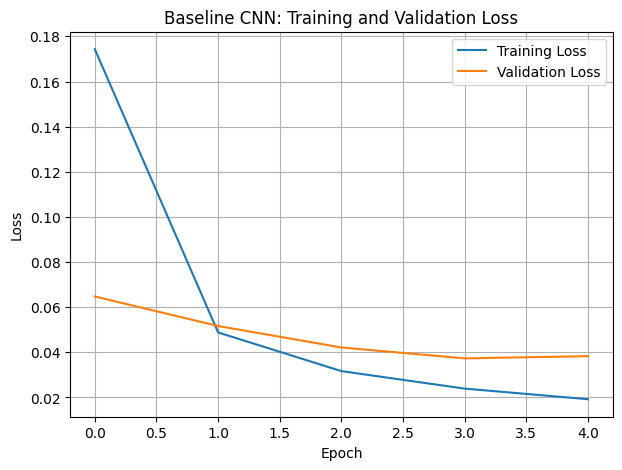

In [18]:
plt.figure(figsize=(7, 5))

plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

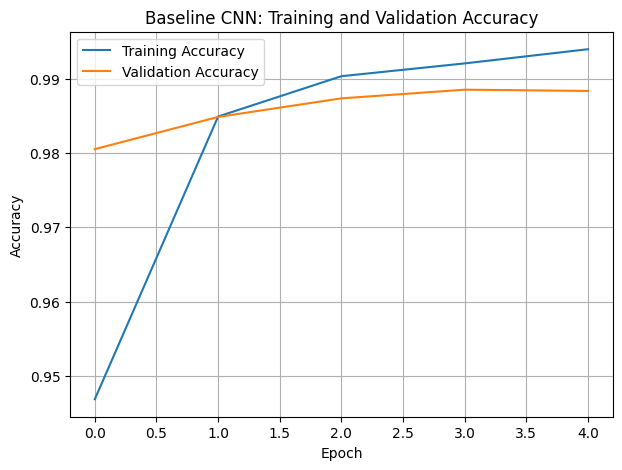

In [19]:
plt.figure(figsize=(7, 5))

plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN: Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [20]:
test_loss, test_accuracy = evaluate(model, test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0301
Test Accuracy: 98.98%


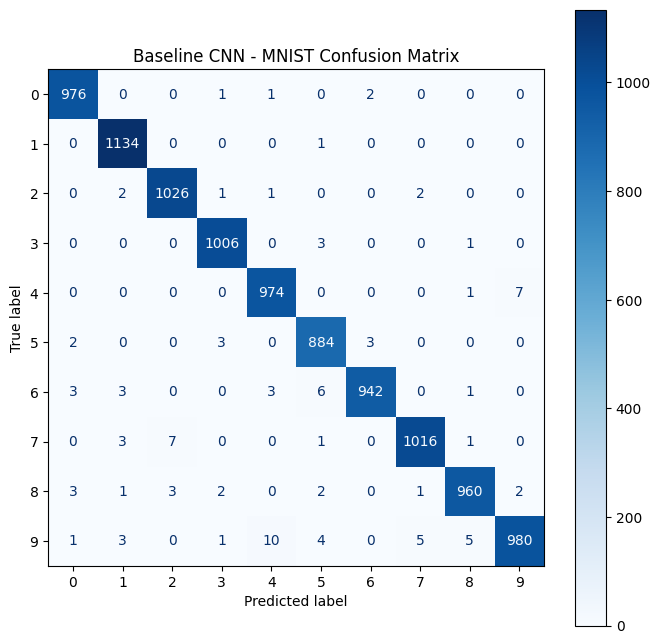

In [21]:
def get_predictions(model, loader):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())

    return np.array(all_labels), np.array(all_predictions)


true_labels, predicted_labels = get_predictions(
    model,
    test_loader
)

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(10))
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline CNN - MNIST Confusion Matrix")
plt.show()

##Q6

In [22]:
class VariantB_StrideCNN(nn.Module):
    """
    Pooling layers removed.
    Downsampling is performed using stride-2 convolutions.
    """
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1, 32, kernel_size=3,
            stride=2, padding=1
        )

        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(
            32, 64, kernel_size=3,
            stride=2, padding=1
        )

        self.relu2 = nn.ReLU()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))

        x = self.flatten(x)

        x = self.relu3(self.fc1(x))
        x = self.fc2(x)

        return x


class VariantC_GELU(nn.Module):
    """
    Same architecture as baseline,
    but ReLU is replaced by GELU.
    """
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.gelu1 = nn.GELU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.gelu2 = nn.GELU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.gelu3 = nn.GELU()

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.gelu1(self.conv1(x))
        x = self.pool1(x)

        x = self.gelu2(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.gelu3(self.fc1(x))
        x = self.fc2(x)

        return x

In [23]:
def run_experiment(model_class, name, epochs=5):
    # Reset seed so every model starts reproducibly
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = model_class().to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    start = time.time()

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"{name} | Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc*100:.2f}%"
        )

    elapsed = time.time() - start

    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return {
        "model": model,
        "history": history,
        "params": params,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "time": elapsed
    }

In [24]:
results = {}

results["A - Baseline"] = run_experiment(
    BaselineCNN,
    "A - Baseline"
)

results["B - Stride-2 Conv"] = run_experiment(
    VariantB_StrideCNN,
    "B - Stride-2 Conv"
)

results["C - GELU"] = run_experiment(
    VariantC_GELU,
    "C - GELU"
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


A - Baseline | Epoch 1/5 | Train Loss: 0.1884 | Val Loss: 0.0728 | Val Acc: 97.87%
A - Baseline | Epoch 2/5 | Train Loss: 0.0481 | Val Loss: 0.0504 | Val Acc: 98.58%
A - Baseline | Epoch 3/5 | Train Loss: 0.0333 | Val Loss: 0.0660 | Val Acc: 98.10%
A - Baseline | Epoch 4/5 | Train Loss: 0.0250 | Val Loss: 0.0457 | Val Acc: 98.63%
A - Baseline | Epoch 5/5 | Train Loss: 0.0190 | Val Loss: 0.0499 | Val Acc: 98.53%
B - Stride-2 Conv | Epoch 1/5 | Train Loss: 0.2354 | Val Loss: 0.0913 | Val Acc: 97.30%
B - Stride-2 Conv | Epoch 2/5 | Train Loss: 0.0621 | Val Loss: 0.0646 | Val Acc: 98.17%
B - Stride-2 Conv | Epoch 3/5 | Train Loss: 0.0438 | Val Loss: 0.0607 | Val Acc: 98.22%
B - Stride-2 Conv | Epoch 4/5 | Train Loss: 0.0300 | Val Loss: 0.0460 | Val Acc: 98.60%
B - Stride-2 Conv | Epoch 5/5 | Train Loss: 0.0225 | Val Loss: 0.0412 | Val Acc: 98.78%
C - GELU | Epoch 1/5 | Train Loss: 0.1553 | Val Loss: 0.0616 | Val Acc: 98.17%
C - GELU | Epoch 2/5 | Train Loss: 0.0408 | Val Loss: 0.0455 | Val

In [25]:
print(f"{'Model':25s} {'Parameters':>15s} {'Test Acc':>12s} {'Time (s)':>12s}")
print("-" * 70)

for name, result in results.items():
    print(
        f"{name:25s} "
        f"{result['params']:15,d} "
        f"{result['test_acc']*100:11.2f}% "
        f"{result['time']:11.2f}"
    )

Model                          Parameters     Test Acc     Time (s)
----------------------------------------------------------------------
A - Baseline                      421,642       98.84%      408.04
B - Stride-2 Conv                 421,642       98.74%      151.62
C - GELU                          421,642       99.05%      462.11


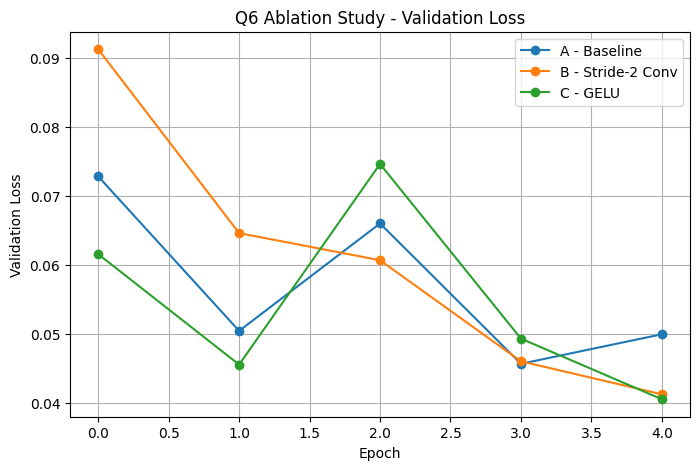

In [26]:
plt.figure(figsize=(8, 5))

for name, result in results.items():
    plt.plot(
        result["history"]["val_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Q6 Ablation Study - Validation Loss")
plt.legend()
plt.grid()

plt.show()

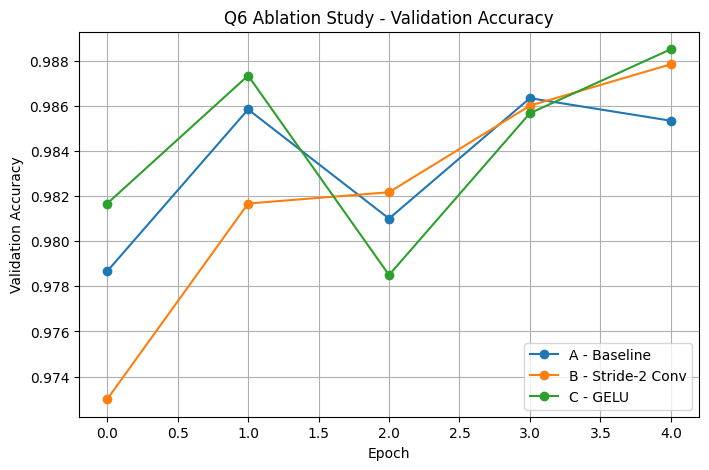

In [27]:
plt.figure(figsize=(8, 5))

for name, result in results.items():
    plt.plot(
        result["history"]["val_acc"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Q6 Ablation Study - Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

##Q7

In [28]:
class CNN_3x3(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class CNN_5x5(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 28, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(28, 56, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(56 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [29]:
model_3x3 = CNN_3x3()
model_5x5 = CNN_5x5()

params_3x3 = sum(
    p.numel() for p in model_3x3.parameters()
    if p.requires_grad
)

params_5x5 = sum(
    p.numel() for p in model_5x5.parameters()
    if p.requires_grad
)

print("3×3 model parameters:", params_3x3)
print("5×5 model parameters:", params_5x5)

print(
    "Difference:",
    abs(params_3x3 - params_5x5)
)

3×3 model parameters: 421642
5×5 model parameters: 392634
Difference: 29008


In [30]:
model_3x3 = CNN_3x3()
model_5x5 = CNN_5x5()

params_3x3 = sum(
    p.numel() for p in model_3x3.parameters()
    if p.requires_grad
)

params_5x5 = sum(
    p.numel() for p in model_5x5.parameters()
    if p.requires_grad
)

print("3×3 model parameters:", params_3x3)
print("5×5 model parameters:", params_5x5)

print(
    "Difference:",
    abs(params_3x3 - params_5x5)
)

3×3 model parameters: 421642
5×5 model parameters: 392634
Difference: 29008


In [32]:
# Q7: Train both kernel-size models

kernel_results = {}

kernel_results["3x3"] = run_experiment(
    CNN_3x3,
    "3x3 CNN"
)

kernel_results["5x5"] = run_experiment(
    CNN_5x5,
    "5x5 CNN"
)

3x3 CNN | Epoch 1/5 | Train Loss: 0.1884 | Val Loss: 0.0728 | Val Acc: 97.87%
3x3 CNN | Epoch 2/5 | Train Loss: 0.0481 | Val Loss: 0.0504 | Val Acc: 98.58%
3x3 CNN | Epoch 3/5 | Train Loss: 0.0333 | Val Loss: 0.0660 | Val Acc: 98.10%
3x3 CNN | Epoch 4/5 | Train Loss: 0.0250 | Val Loss: 0.0457 | Val Acc: 98.63%
3x3 CNN | Epoch 5/5 | Train Loss: 0.0190 | Val Loss: 0.0499 | Val Acc: 98.53%
5x5 CNN | Epoch 1/5 | Train Loss: 0.1635 | Val Loss: 0.0608 | Val Acc: 98.28%
5x5 CNN | Epoch 2/5 | Train Loss: 0.0465 | Val Loss: 0.0514 | Val Acc: 98.53%
5x5 CNN | Epoch 3/5 | Train Loss: 0.0303 | Val Loss: 0.0418 | Val Acc: 98.75%
5x5 CNN | Epoch 4/5 | Train Loss: 0.0234 | Val Loss: 0.0390 | Val Acc: 98.85%
5x5 CNN | Epoch 5/5 | Train Loss: 0.0170 | Val Loss: 0.0357 | Val Acc: 98.92%


In [33]:
print(f"{'Model':15s} {'Parameters':>15s} {'Test Accuracy':>18s} {'Time (s)':>12s}")
print("-" * 65)

for name, result in kernel_results.items():
    print(
        f"{name:15s} "
        f"{result['params']:15,d} "
        f"{result['test_acc']*100:17.2f}% "
        f"{result['time']:11.2f}"
    )

Model                Parameters      Test Accuracy     Time (s)
-----------------------------------------------------------------
3x3                     421,642             98.84%      408.22
5x5                     392,634             99.16%      539.54


### Why stacked 3×3 convolutions are powerful

A single 5×5 convolution has a 5×5 receptive field.

Two consecutive 3×3 convolutions also provide an effective 5×5 receptive field:

3 + (3 - 1) = 5

However, two 3×3 convolutions introduce an additional nonlinear activation between them.

For the same number of channels, two 3×3 convolutions require:

3×3 + 3×3 = 18 weight units per input-output channel pair,

whereas one 5×5 convolution requires:

5×5 = 25 weight units.

Therefore, stacked 3×3 convolutions can provide a comparable receptive field with fewer parameters and additional nonlinear feature transformations.

##Q8

In [34]:
class MaxPoolCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = torch.relu(self.conv1(x))

        before_pool1 = x
        x = self.pool(x)
        after_pool1 = x

        x = torch.relu(self.conv2(x))

        before_pool2 = x
        x = self.pool(x)
        after_pool2 = x

        return x, before_pool1, after_pool1, before_pool2, after_pool2


class AveragePoolCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.AvgPool2d(2, 2)

    def forward(self, x):
        x = torch.relu(self.conv1(x))

        before_pool1 = x
        x = self.pool(x)
        after_pool1 = x

        x = torch.relu(self.conv2(x))

        before_pool2 = x
        x = self.pool(x)
        after_pool2 = x

        return x, before_pool1, after_pool1, before_pool2, after_pool2


class NoPoolCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1, 32, 3,
            stride=2,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            32, 64, 3,
            stride=2,
            padding=1
        )

    def forward(self, x):
        before_downsample1 = torch.relu(
            nn.functional.conv2d(
                x,
                self.conv1.weight,
                self.conv1.bias,
                stride=1,
                padding=1
            )
        )

        x = torch.relu(self.conv1(x))
        after_downsample1 = x

        before_downsample2 = torch.relu(
            nn.functional.conv2d(
                x,
                self.conv2.weight,
                self.conv2.bias,
                stride=1,
                padding=1
            )
        )

        x = torch.relu(self.conv2(x))
        after_downsample2 = x

        return x, before_downsample1, after_downsample1, before_downsample2, after_downsample2

True label: 7
Input shape: torch.Size([1, 1, 28, 28])


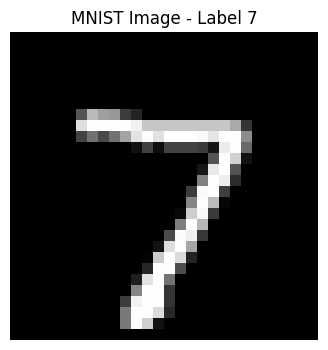

In [35]:
# Get one MNIST test image
image, label = test_dataset[0]

image_batch = image.unsqueeze(0).to(device)

print("True label:", label)
print("Input shape:", image_batch.shape)

# Display image
plt.figure(figsize=(4, 4))

plt.imshow(
    image.squeeze().numpy(),
    cmap="gray"
)

plt.title(f"MNIST Image - Label {label}")
plt.axis("off")

plt.show()

In [36]:
max_model = MaxPoolCNN().to(device)
avg_model = AveragePoolCNN().to(device)
nopool_model = NoPoolCNN().to(device)

max_model.eval()
avg_model.eval()
nopool_model.eval()

with torch.no_grad():
    _, max_before, max_after, _, _ = max_model(image_batch)
    _, avg_before, avg_after, _, _ = avg_model(image_batch)
    _, no_before, no_after, _, _ = nopool_model(image_batch)

# Select first feature map
max_before_map = max_before[0, 0].cpu().numpy()
max_after_map = max_after[0, 0].cpu().numpy()

avg_before_map = avg_before[0, 0].cpu().numpy()
avg_after_map = avg_after[0, 0].cpu().numpy()

no_before_map = no_before[0, 0].cpu().numpy()
no_after_map = no_after[0, 0].cpu().numpy()

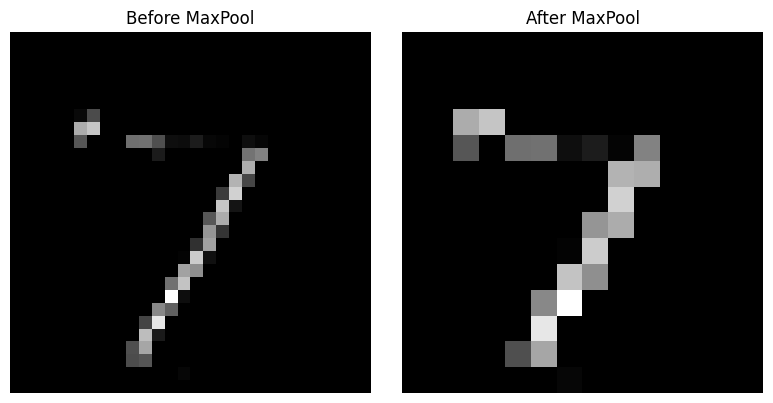

In [37]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(max_before_map, cmap="gray")
plt.title("Before MaxPool")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(max_after_map, cmap="gray")
plt.title("After MaxPool")
plt.axis("off")

plt.tight_layout()
plt.show()

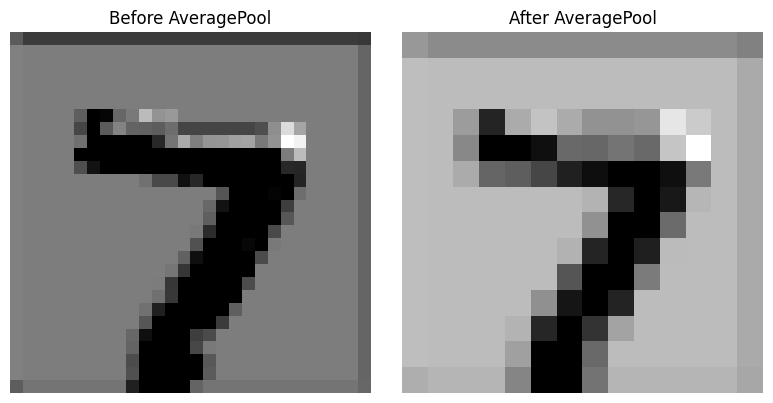

In [38]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(avg_before_map, cmap="gray")
plt.title("Before AveragePool")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(avg_after_map, cmap="gray")
plt.title("After AveragePool")
plt.axis("off")

plt.tight_layout()
plt.show()

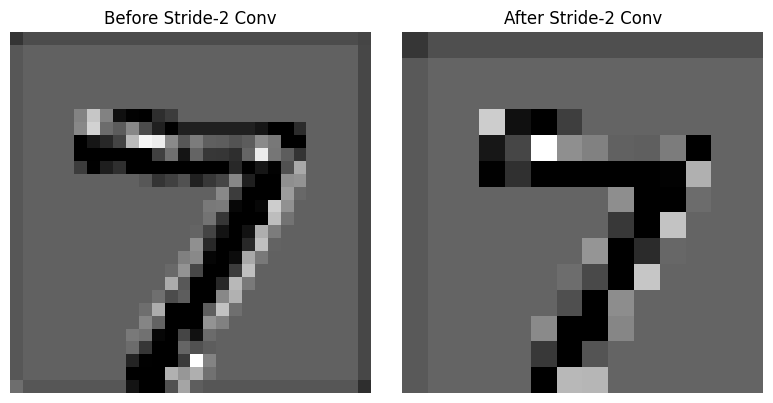

In [39]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(no_before_map, cmap="gray")
plt.title("Before Stride-2 Conv")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(no_after_map, cmap="gray")
plt.title("After Stride-2 Conv")
plt.axis("off")

plt.tight_layout()
plt.show()

## Q9. Feature-Map Sensitivity

A trained baseline CNN is used to investigate the sensitivity of learned feature representations.

One MNIST test image is selected and passed through the network. Feature maps are extracted after the first and second convolutional blocks.

A controlled Gaussian-noise perturbation is then added to the input while keeping the ground-truth label unchanged.

The original and perturbed feature representations are compared using:

1. Relative L2 distance
2. Cosine similarity

Relative L2 distance is defined as:

D = ||F_perturbed - F_original||₂ / ||F_original||₂

A smaller relative distance and higher cosine similarity indicate greater feature-level robustness.

In [40]:
# Q9: Feature extraction from the trained baseline model

def extract_features(model, image):
    model.eval()

    with torch.no_grad():
        # First convolutional block
        x1 = model.conv1(image)
        x1 = model.relu1(x1)

        # First pooling
        p1 = model.pool1(x1)

        # Second convolutional block
        x2 = model.conv2(p1)
        x2 = model.relu2(x2)

        # Second pooling
        p2 = model.pool2(x2)

    return x1, x2, p1, p2

In [41]:
# Select a test image
image, true_label = test_dataset[0]

image = image.unsqueeze(0).to(device)

print("True label:", true_label)
print("Input shape:", image.shape)

True label: 7
Input shape: torch.Size([1, 1, 28, 28])


In [42]:
# Reproducible Gaussian noise
torch.manual_seed(SEED)

noise_std = 0.10

noise = torch.randn_like(image) * noise_std

perturbed_image = image + noise

print("Noise standard deviation:", noise_std)

Noise standard deviation: 0.1


In [43]:
original_f1, original_f2, _, _ = extract_features(
    model,
    image
)

perturbed_f1, perturbed_f2, _, _ = extract_features(
    model,
    perturbed_image
)

print("First block feature map:", original_f1.shape)
print("Second block feature map:", original_f2.shape)

First block feature map: torch.Size([1, 32, 28, 28])
Second block feature map: torch.Size([1, 64, 14, 14])


In [44]:
import torch.nn.functional as F

def relative_l2(original, perturbed):
    return (
        torch.norm(perturbed - original)
        / torch.norm(original)
    ).item()


def cosine_similarity(original, perturbed):
    original_flat = original.flatten(1)
    perturbed_flat = perturbed.flatten(1)

    return F.cosine_similarity(
        original_flat,
        perturbed_flat,
        dim=1
    ).item()


# First convolution block
rel_l2_f1 = relative_l2(
    original_f1,
    perturbed_f1
)

cos_f1 = cosine_similarity(
    original_f1,
    perturbed_f1
)

# Second convolution block
rel_l2_f2 = relative_l2(
    original_f2,
    perturbed_f2
)

cos_f2 = cosine_similarity(
    original_f2,
    perturbed_f2
)

print("Q9 Feature Sensitivity")
print("-" * 50)

print(f"First block:")
print(f"  Relative L2 distance : {rel_l2_f1:.6f}")
print(f"  Cosine similarity    : {cos_f1:.6f}")

print()

print(f"Second block:")
print(f"  Relative L2 distance : {rel_l2_f2:.6f}")
print(f"  Cosine similarity    : {cos_f2:.6f}")

Q9 Feature Sensitivity
--------------------------------------------------
First block:
  Relative L2 distance : 0.114658
  Cosine similarity    : 0.993456

Second block:
  Relative L2 distance : 0.063832
  Cosine similarity    : 0.998139


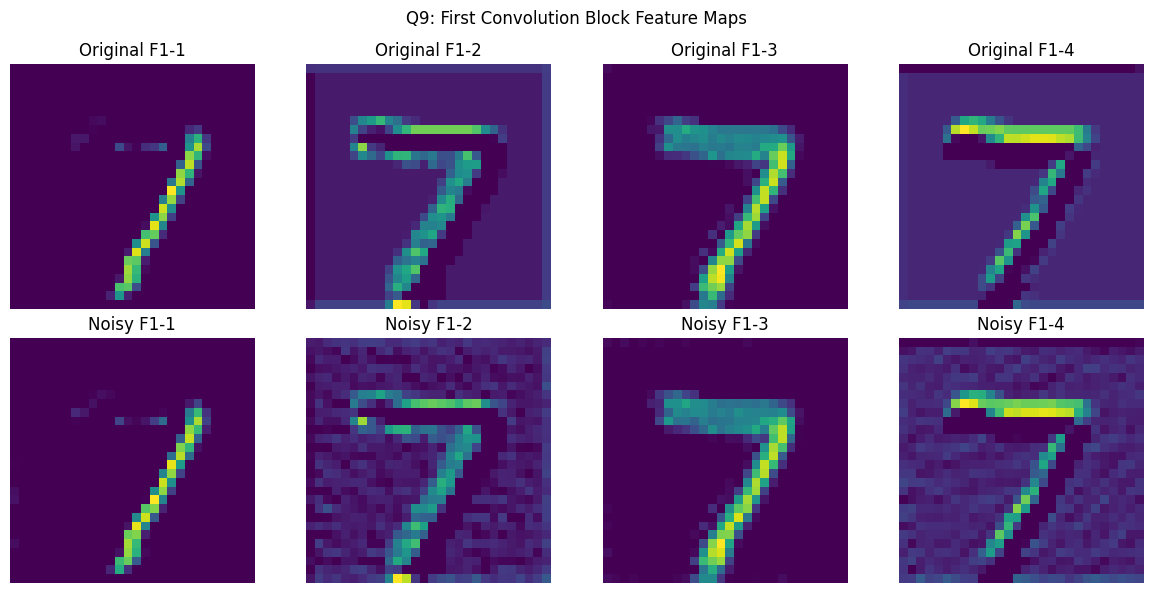

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    axes[0, i].imshow(
        original_f1[0, i].cpu().numpy(),
        cmap="viridis"
    )
    axes[0, i].set_title(f"Original F1-{i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(
        perturbed_f1[0, i].cpu().numpy(),
        cmap="viridis"
    )
    axes[1, i].set_title(f"Noisy F1-{i+1}")
    axes[1, i].axis("off")

plt.suptitle("Q9: First Convolution Block Feature Maps")
plt.tight_layout()
plt.show()

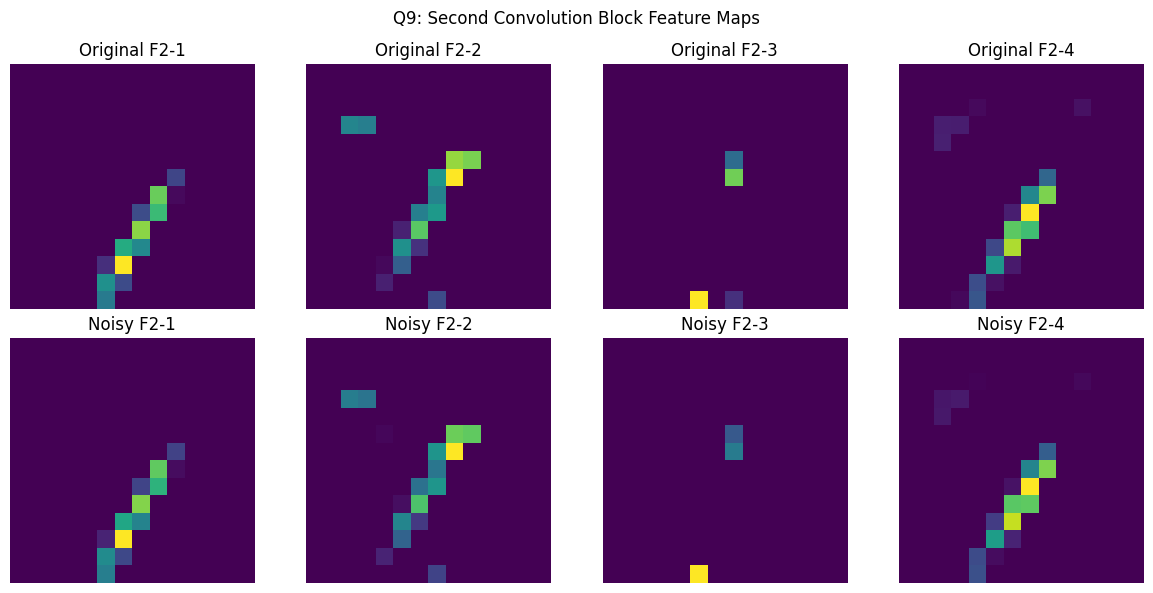

In [46]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    axes[0, i].imshow(
        original_f2[0, i].cpu().numpy(),
        cmap="viridis"
    )
    axes[0, i].set_title(f"Original F2-{i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(
        perturbed_f2[0, i].cpu().numpy(),
        cmap="viridis"
    )
    axes[1, i].set_title(f"Noisy F2-{i+1}")
    axes[1, i].axis("off")

plt.suptitle("Q9: Second Convolution Block Feature Maps")
plt.tight_layout()
plt.show()

In [47]:
def get_prediction(model, image):
    model.eval()

    with torch.no_grad():
        output = model(image)
        probabilities = torch.softmax(output, dim=1)

        predicted_class = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_class].item()

    return predicted_class, confidence, probabilities


original_pred, original_conf, original_probs = get_prediction(
    model,
    image
)

perturbed_pred, perturbed_conf, perturbed_probs = get_prediction(
    model,
    perturbed_image
)

print("Original:")
print("Predicted class:", original_pred)
print("Confidence:", f"{original_conf*100:.2f}%")

print("\nPerturbed:")
print("Predicted class:", perturbed_pred)
print("Confidence:", f"{perturbed_conf*100:.2f}%")

Original:
Predicted class: 7
Confidence: 100.00%

Perturbed:
Predicted class: 7
Confidence: 100.00%


## Q10. Translation Experiment

To investigate translation sensitivity, selected MNIST images are translated horizontally by several pixels while keeping their labels unchanged.

Translations of -4, -2, 0, +2, and +4 pixels are considered.

For each translated image, the following are measured:

1. Predicted class
2. Prediction confidence
3. Change in confidence relative to the original image
4. Cosine similarity between the original and translated second-block feature representations

The experiment distinguishes between:

Translation equivariance:
A translated input produces a correspondingly translated feature representation.

Translation invariance:
The final prediction remains stable despite changes in input position.

Convolution is approximately translation equivariant, whereas the complete CNN classifier may become partially translation invariant due to pooling, downsampling, and subsequent aggregation.

In [48]:
def translate_image(image, dx=0, dy=0):
    """
    Translate an image using zero padding.
    Positive dx = right
    Negative dx = left
    Positive dy = down
    Negative dy = up
    """

    translated = torch.zeros_like(image)

    _, _, h, w = image.shape

    src_x_start = max(0, -dx)
    src_x_end = min(w, w - dx) if dx >= 0 else w

    src_y_start = max(0, -dy)
    src_y_end = min(h, h - dy) if dy >= 0 else h

    dst_x_start = max(0, dx)
    dst_x_end = dst_x_start + (src_x_end - src_x_start)

    dst_y_start = max(0, dy)
    dst_y_end = dst_y_start + (src_y_end - src_y_start)

    if src_x_end > src_x_start and src_y_end > src_y_start:
        translated[
            :,
            :,
            dst_y_start:dst_y_end,
            dst_x_start:dst_x_end
        ] = image[
            :,
            :,
            src_y_start:src_y_end,
            src_x_start:src_x_end
        ]

    return translated

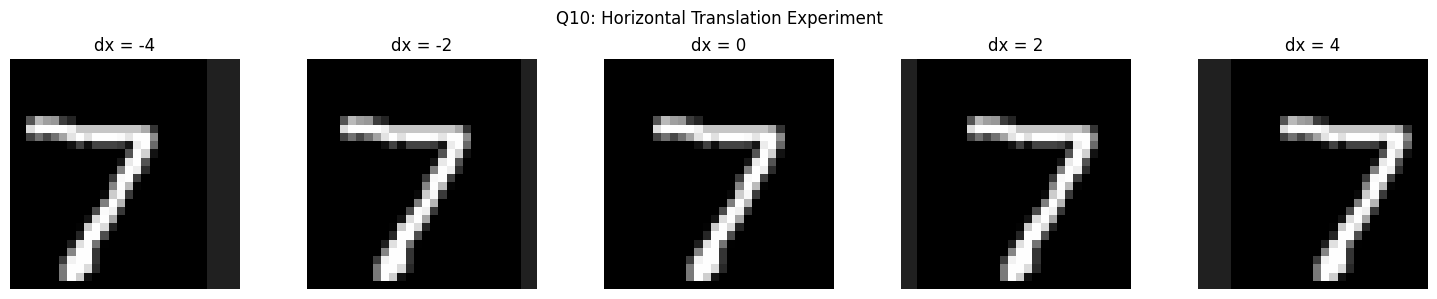

In [49]:
translations = [-4, -2, 0, 2, 4]

fig, axes = plt.subplots(
    1,
    len(translations),
    figsize=(15, 3)
)

for ax, dx in zip(axes, translations):

    translated = translate_image(
        image,
        dx=dx
    )

    ax.imshow(
        translated[0, 0].cpu().numpy(),
        cmap="gray"
    )

    ax.set_title(f"dx = {dx}")
    ax.axis("off")

plt.suptitle("Q10: Horizontal Translation Experiment")
plt.tight_layout()
plt.show()

In [50]:
translation_results = []

# Original second-block representation
original_f1, original_f2, _, _ = extract_features(
    model,
    image
)

original_pred, original_conf, _ = get_prediction(
    model,
    image
)

for dx in translations:

    translated = translate_image(
        image,
        dx=dx
    )

    pred, confidence, probabilities = get_prediction(
        model,
        translated
    )

    _, translated_f2, _, _ = extract_features(
        model,
        translated
    )

    feature_similarity = cosine_similarity(
        original_f2,
        translated_f2
    )

    confidence_change = confidence - original_conf

    translation_results.append({
        "translation": dx,
        "prediction": pred,
        "confidence": confidence,
        "confidence_change": confidence_change,
        "feature_cosine_similarity": feature_similarity
    })

translation_results

[{'translation': -4,
  'prediction': 7,
  'confidence': 0.9999700784683228,
  'confidence_change': -2.7894973754882812e-05,
  'feature_cosine_similarity': 0.29856276512145996},
 {'translation': -2,
  'prediction': 7,
  'confidence': 0.9999963045120239,
  'confidence_change': -1.6689300537109375e-06,
  'feature_cosine_similarity': 0.5311227440834045},
 {'translation': 0,
  'prediction': 7,
  'confidence': 0.9999979734420776,
  'confidence_change': 0.0,
  'feature_cosine_similarity': 1.0},
 {'translation': 2,
  'prediction': 7,
  'confidence': 0.9999706745147705,
  'confidence_change': -2.7298927307128906e-05,
  'feature_cosine_similarity': 0.5307804346084595},
 {'translation': 4,
  'prediction': 7,
  'confidence': 0.9985589385032654,
  'confidence_change': -0.0014390349388122559,
  'feature_cosine_similarity': 0.29898741841316223}]

In [51]:
import pandas as pd

translation_df = pd.DataFrame(
    translation_results
)

translation_df["confidence"] *= 100
translation_df["confidence_change"] *= 100

translation_df

,translation,prediction,confidence,confidence_change,feature_cosine_similarity
0,-4,7,99.997008,-0.002789,0.298563
1,-2,7,99.999630,-0.000167,0.531123
2,0,7,99.999797,0.000000,1.000000
3,2,7,99.997067,-0.002730,0.530780
4,4,7,99.855894,-0.143903,0.298987


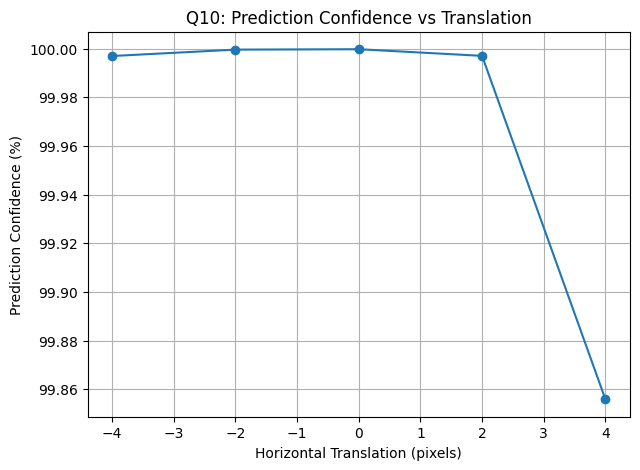

In [52]:
plt.figure(figsize=(7, 5))

plt.plot(
    translation_df["translation"],
    translation_df["confidence"],
    marker="o"
)

plt.xlabel("Horizontal Translation (pixels)")
plt.ylabel("Prediction Confidence (%)")
plt.title("Q10: Prediction Confidence vs Translation")
plt.grid()

plt.show()

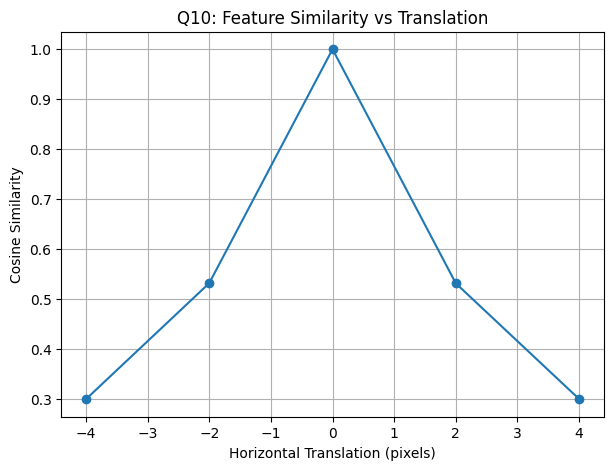

In [53]:
plt.figure(figsize=(7, 5))

plt.plot(
    translation_df["translation"],
    translation_df["feature_cosine_similarity"],
    marker="o"
)

plt.xlabel("Horizontal Translation (pixels)")
plt.ylabel("Cosine Similarity")
plt.title("Q10: Feature Similarity vs Translation")
plt.grid()

plt.show()

### Translation Equivariance vs Translation Invariance

A convolution operation is translation equivariant. If an input feature is translated spatially, the corresponding convolutional activation also moves spatially.

Mathematically, for an ideal convolution operation:

f(Tx) ≈ T(f(x))

where T represents a translation.

However, equivariance does not mean that the output remains numerically identical.

A complete CNN classifier can become partially translation invariant because pooling, downsampling, and fully connected classification layers reduce sensitivity to the exact spatial location of features.

Therefore:

Translation equivariance:
The feature representation changes location when the input changes location.

Translation invariance:
The final classification remains stable despite the change in location.

The experiment measures both effects by comparing intermediate feature representations and final prediction confidence.